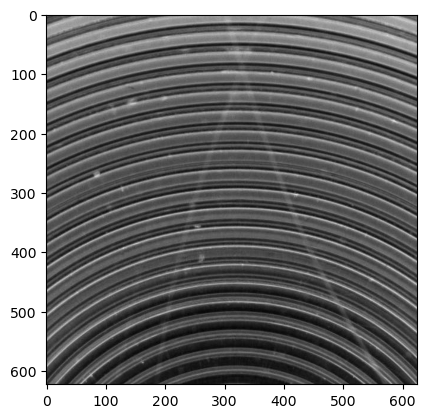

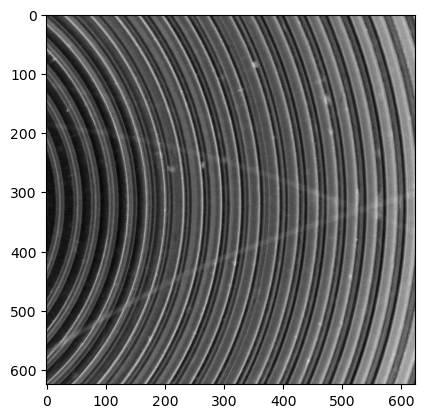

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('image1.png', 0)
img2 = cv2.imread('image2.png', 0)
img3 = cv2.imread('image3.png', 0)

cimg = cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(img1,cv2.HOUGH_GRADIENT,1,30,
                            param1=50,param2=30,minRadius=300,maxRadius=1000)
 
circles = np.uint16(np.around(circles))
for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(cimg,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv2.circle(cimg,(i[0],i[1]),2,(0,0,255),3)
 
cv2.imshow('detected circles',cimg)

plt.imshow(cimg, cmap='gray')
plt.show()
plt.imshow(img1, cmap='gray')

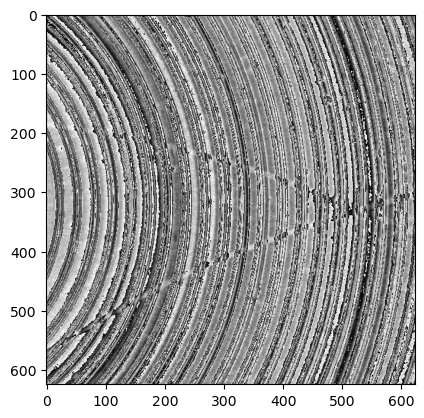

In [44]:
[N,M] = img1.shape

new_image = img1.copy()

for n in range(N):
    for m in range(M):
        new_image[n,m] = np.power(new_image[n,m],1.5)
        

plt.imshow(new_image, cmap='gray')

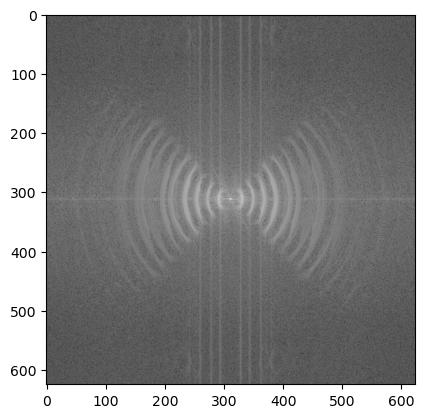

In [45]:
f1 = np.fft.fft2(img1)
fshift1 = np.fft.fftshift(f1)
magnitude_spectrum = 20*np.log(np.abs(fshift1))

plt.imshow(magnitude_spectrum, cmap='gray')

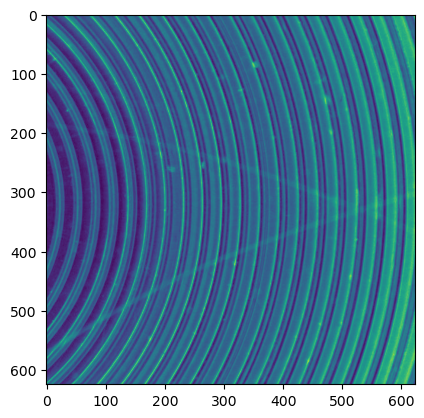

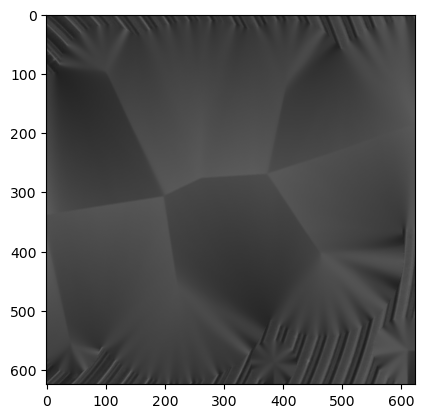

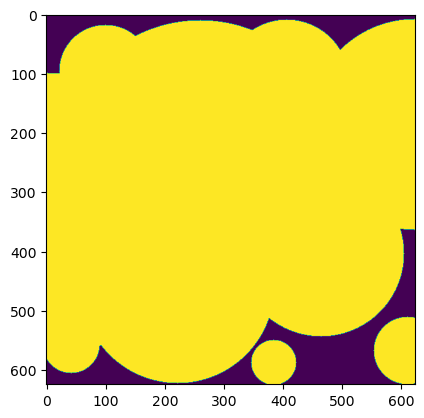

In [69]:
import cv2
import numpy as np

def remove_concentric_circles(image_path, output_path):
    # Load the image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 3)

    # Detect circles using Hough Circle Transform
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=200,
        param1=50,
        param2=30,
        minRadius=10,
        maxRadius=0
    )

    # Create a mask for inpainting
    mask = np.zeros_like(gray)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            center = (circle[0], circle[1])  # (x, y) center
            radius = circle[2]  # radius
            # Draw the circle on the mask
            cv2.circle(mask, center, radius, 255, thickness=-1)

    # Inpaint the image to remove the circles
    inpainted = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    # Save the result
    ## cv2.imwrite(output_path, inpainted)
    ## print(f"Processed image saved at {output_path}")
    
    plt.imshow(inpainted)
    plt.show()
    
    return mask

# Example usage
image_path = "image1.png"  # Replace with your input image path
output_path = "output_image.jpg"  # Replace with your desired output path
plt.imshow(img1)
plt.show()

mask = remove_concentric_circles(image_path, output_path)
plt.imshow(mask)
plt.show()
